In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os 

# SETUP FOLDER PENYIMPANAN GAMBAR
# Membuat folder khusus untuk menyimpan hasil visualisasi dataset Glass
save_dir = '../output/figures/glass/'
os.makedirs(save_dir, exist_ok=True)
print(f"📂 Folder penyimpanan gambar siap di: {save_dir}")

📂 Folder penyimpanan gambar siap di: ../output/figures/glass/


In [21]:
# ==========================================
# 2. MEMUAT DATASET (DATA LOADING)
# ==========================================
# Membaca file CSV mentah
dataset = pd.read_csv('../data/glass.csv')

# Menampilkan 5 baris data teratas
dataset.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,label
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,A
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,A
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,A
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,A
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,A


In [22]:
# ==========================================
# 3. PEMERIKSAAN TIPE DATA (DATA TYPES)
# ==========================================
# Mengecek tipe data (float/object) dan jumlah memori yang digunakan
check_type_2 = dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   label   214 non-null    object 
dtypes: float64(9), object(1)
memory usage: 16.8+ KB


In [23]:
# ==========================================
# 4. CEK KONSISTENSI LABEL (CATEGORICAL CHECK)
# ==========================================
print("\n--- Pengecekan Nilai Unik pada Kolom Object ---")

# Mengambil kolom non-angka (biasanya label kelas)
kolom_object = dataset.select_dtypes(include=['object']).columns

# Menampilkan daftar kelas yang ada (misal: 'A', 'B', 'C')
for col in kolom_object:
    print(f"\nNilai unik di kolom '{col}':")
    print(dataset[col].unique())
    print(f"Jumlah nilai unik: {len(dataset[col].unique())}")


--- Pengecekan Nilai Unik pada Kolom Object ---

Nilai unik di kolom 'label':
['A' 'B' 'C' 'E' 'F' 'G']
Jumlah nilai unik: 6


In [24]:
# ==========================================
# 5. CEK & HAPUS DUPLIKASI (DUPLICATE HANDLING)
# ==========================================
# Menghitung jumlah baris duplikat
check_duplicate = dataset.duplicated().sum()
print(f"Jumlah dataset duplikat: {check_duplicate}")

# Logika penghapusan otomatis jika ada duplikat
if check_duplicate > 0:
    dataset.drop_duplicates(inplace=True)
    dataset.reset_index(drop=True, inplace=True) # Reset index agar urut kembali
    
    print(f"\n✅ Berhasil menghapus {check_duplicate} data duplikat.")
    print(f"Total baris data sekarang: {len(dataset)}")
else:
    print("✅ Tidak ditemukan duplikasi data.")

Jumlah dataset duplikat: 1

✅ Berhasil menghapus 1 data duplikat.
Total baris data sekarang: 213


In [25]:
# ==========================================
# 6. CEK MISSING VALUES (DATA KOSONG)
# ==========================================
# Menghitung jumlah NaN per kolom
check_null = dataset.isna().sum()

if check_null.sum() > 0:
    print(f"\nKolom dengan Missing Values:")
    print(f"{check_null[check_null > 0]}")
else:
    print(f"✅ Tidak ditemukan data kosong (Clean).")

✅ Tidak ditemukan data kosong (Clean).


In [26]:
# ==========================================
# 6. CEK MISSING VALUES (DATA KOSONG)
# ==========================================
# Menghitung jumlah NaN per kolom
check_null = dataset.isna().sum()

if check_null.sum() > 0:
    print(f"\nKolom dengan Missing Values:")
    print(f"{check_null[check_null > 0]}")
else:
    print(f"✅ Tidak ditemukan data kosong (Clean).")

✅ Tidak ditemukan data kosong (Clean).


In [27]:
# ==========================================
# 7. VALIDASI LOGIKA (DOMAIN KNOWLEDGE CHECK)
# ==========================================
# Tahap ini memverifikasi apakah data masuk akal secara Fisika/Kimia
print("\n--- MEMULAI PENGECEKAN LOGIKA KIMIA/FISIKA ---")

error_report = []
glass_columns = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

# [A] Validasi Tipe Data Numerik (Pastikan tidak ada teks nyasar)
for col in glass_columns:
    if col in dataset.columns:
        test_convert = pd.to_numeric(dataset[col], errors='coerce')
        new_nans = test_convert.isna().sum() - dataset[col].isna().sum()
        
        if new_nans > 0:
            error_report.append(f"[TIPE DATA] Kolom '{col}': Ditemukan {new_nans} non-angka.")
        else:
            print(f"✓ Kolom '{col}' format data aman (numerik).")

# [B] Pengecekan Nilai Tidak Logis (Negative Values)
logic_rules = []

# Aturan 1: Refractive Index (RI) tidak mungkin 0 atau negatif
if 'RI' in dataset.columns:
    logic_rules.append(('RI', dataset['RI'] <= 0, "Refractive Index <= 0 (Mustahil)"))

# Aturan 2: Kandungan Kimia (Na, Mg, dll) tidak boleh negatif
chemical_elements = ['Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
for chem in chemical_elements:
    if chem in dataset.columns:
        logic_rules.append((chem, dataset[chem] < 0, f"Kandungan {chem} bernilai negatif"))

# Eksekusi Pengecekan
for col_name, condition, message in logic_rules:
    if condition.sum() > 0:
        error_report.append(f"[LOGIKA] Kolom '{col_name}': {message}")
        print(f"\n! WARNING: {message}")
        display(dataset[condition].head(3))

# Laporan Akhir Validasi
print("\n" + "="*40)
print("LAPORAN AKHIR VALIDASI DATA GLASS")
print("="*40)
if len(error_report) > 0:
    print("⚠️ DITEMUKAN POTENSI KESALAHAN INPUT:")
    for i, err in enumerate(error_report, 1):
        print(f"{i}. {err}")
else:
    print("✅ STATUS: AMAN. Data valid secara logika.")


--- MEMULAI PENGECEKAN LOGIKA KIMIA/FISIKA ---
✓ Kolom 'RI' format data aman (numerik).
✓ Kolom 'Na' format data aman (numerik).
✓ Kolom 'Mg' format data aman (numerik).
✓ Kolom 'Al' format data aman (numerik).
✓ Kolom 'Si' format data aman (numerik).
✓ Kolom 'K' format data aman (numerik).
✓ Kolom 'Ca' format data aman (numerik).
✓ Kolom 'Ba' format data aman (numerik).
✓ Kolom 'Fe' format data aman (numerik).

LAPORAN AKHIR VALIDASI DATA GLASS
✅ STATUS: AMAN. Data valid secara logika.


In [28]:
# ==========================================
# 9. DETEKSI OUTLIER (METODE IQR)
# ==========================================
print("--- Memulai Perhitungan IQR (Outlier Detection) ---")

outlier_summary = []
outlier_details = {} 

for col in numerical_cols:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_details[col] = {'lower': lower_bound, 'upper': upper_bound}
    
    total_outliers = ((dataset[col] < lower_bound) | (dataset[col] > upper_bound)).sum()
    
    if total_outliers > 0:
        outlier_summary.append({
            'Kolom': col,
            'Outliers': total_outliers,
            'Batas Bawah': round(lower_bound, 2),
            'Batas Atas': round(upper_bound, 2)
        })

if len(outlier_summary) > 0:
    print(f"\nRincian Outlier Ditemukan (Total {len(outlier_summary)} kolom):")
    display(pd.DataFrame(outlier_summary))
else:
    print("\nTidak ditemukan outlier yang signifikan.")

--- Memulai Perhitungan IQR (Outlier Detection) ---

Rincian Outlier Ditemukan (Total 8 kolom):


,Kolom,Outliers,Batas Bawah,Batas Atas
0,RI,17,1.51,1.52
1,Na,7,11.54,15.18
2,Al,17,0.53,2.29
3,Si,12,71.06,74.31
4,K,7,-0.59,1.33
5,Ca,27,6.88,10.52
6,Ba,38,0.00,0.00
7,Fe,12,-0.15,0.25



--- Visualisasi Sebaran Outlier (Boxplot Analysis) ---
📸 Gambar tersimpan: analisis_outlier_glass.png


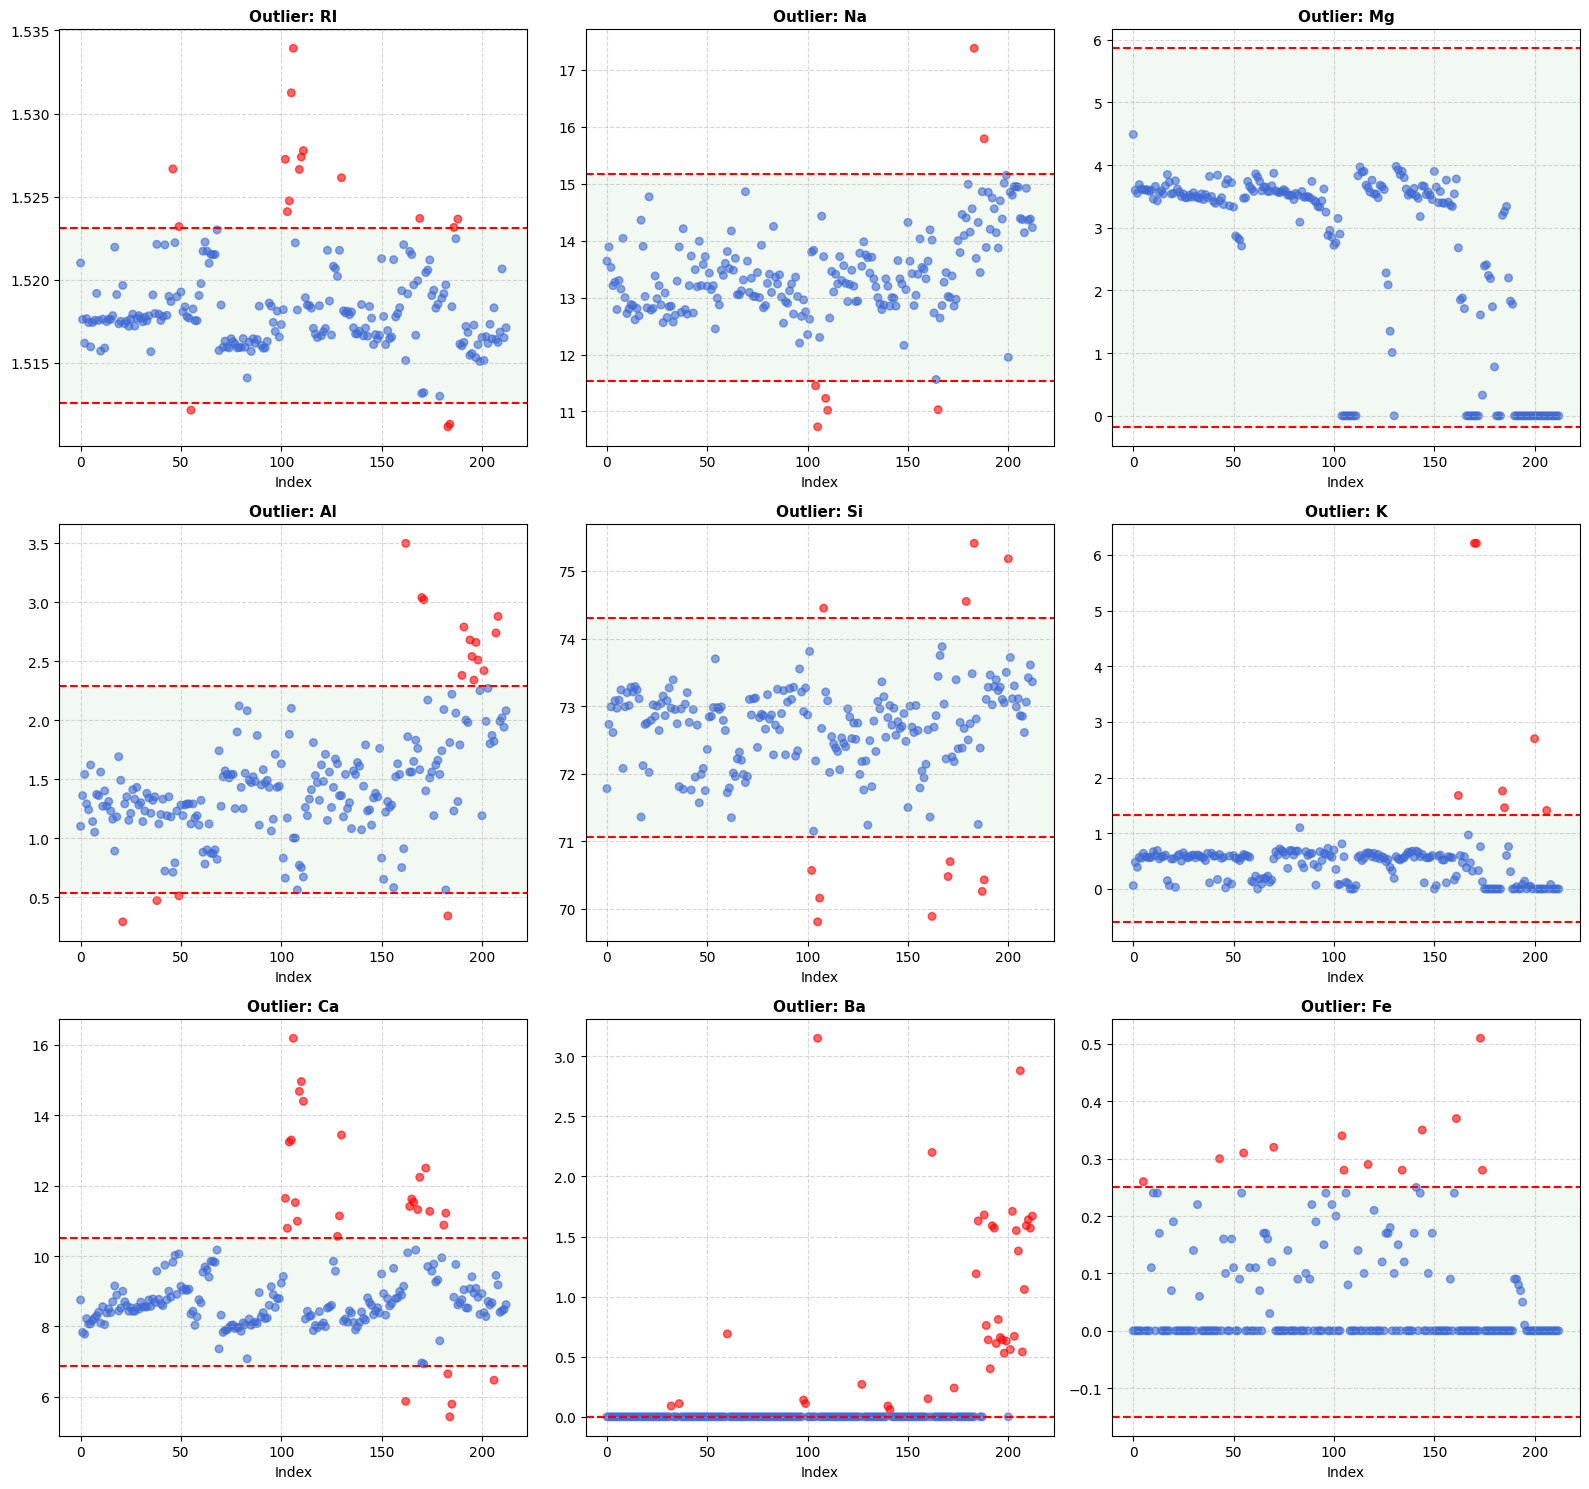

In [29]:
# ==========================================
# 10. VISUALISASI OUTLIER (GRID PLOT)
# ==========================================
print("\n--- Visualisasi Sebaran Outlier (Boxplot Analysis) ---")

# Setup Canvas Grid Otomatis
n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = axes.flatten() # Ratakan array axes

for i, col in enumerate(numerical_cols):
    ax = axes[i]
    
    # Ambil batas IQR
    lb = outlier_details[col]['lower']
    ub = outlier_details[col]['upper']
    
    # Warna: Merah jika outlier, Biru jika normal
    colors = ['red' if (x < lb or x > ub) else 'royalblue' for x in dataset[col]]
    
    # Scatter Plot
    ax.scatter(dataset.index, dataset[col], c=colors, s=30, alpha=0.6)
    
    # Garis Batas
    ax.axhline(y=ub, color='red', linestyle='--', label='Upper Bound')
    ax.axhline(y=lb, color='red', linestyle='--', label='Lower Bound')
    ax.axhspan(lb, ub, color='green', alpha=0.05, label='Normal Range')
    
    ax.set_title(f'Outlier: {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Index')
    ax.grid(True, linestyle='--', alpha=0.5)

# Hapus subplot kosong sisa
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

# Simpan Gambar
nama_file_outlier = 'analisis_outlier_glass.png'
plt.savefig(os.path.join(save_dir, nama_file_outlier), dpi=300, bbox_inches='tight')
print(f"📸 Gambar tersimpan: {nama_file_outlier}")

plt.show()


--- Analisis Kemiringan Distribusi Data (Skewness) ---
📸 Gambar tersimpan: distribusi_skewness_glass.png


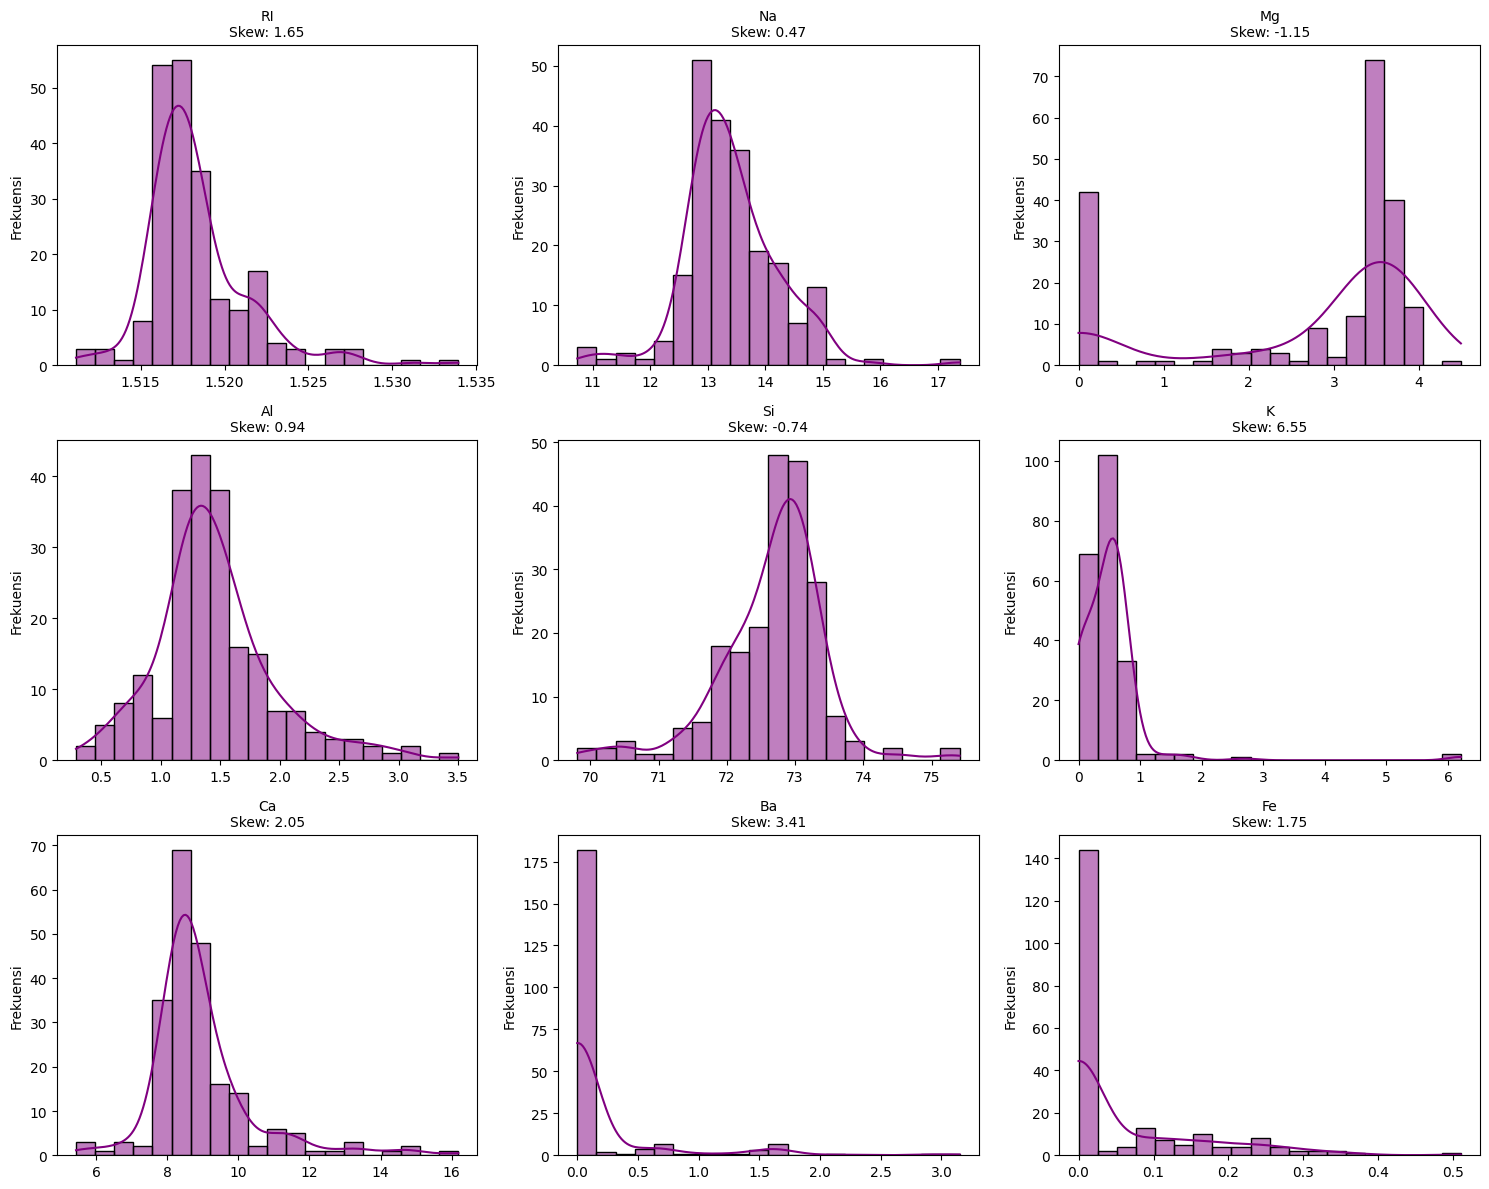


Ringkasan Skewness:


,Kolom,Skewness,Status
0,RI,1.65,Highly Skewed (Kanan)
1,Na,0.47,Normal
2,Mg,-1.15,Highly Skewed (Kiri)
3,Al,0.94,Moderately Skewed
4,Si,-0.74,Moderately Skewed
5,K,6.55,Highly Skewed (Kanan)
6,Ca,2.05,Highly Skewed (Kanan)
7,Ba,3.41,Highly Skewed (Kanan)
8,Fe,1.75,Highly Skewed (Kanan)


In [30]:
# ==========================================
# 8. CEK DISTRIBUSI DATA (SKEWNESS)
# ==========================================
print("\n--- Analisis Kemiringan Distribusi Data (Skewness) ---")

numerical_cols = dataset.select_dtypes(include=['int64', 'float64']).columns
skewness_summary = []

# Setup Canvas Grid
import math
n_cols = 3 
n_rows = math.ceil(len(numerical_cols) / n_cols)
plt.figure(figsize=(15, 4 * n_rows))

for i, col in enumerate(numerical_cols):
    # Hitung nilai Skewness
    sk_value = dataset[col].skew()
    
    status = "Normal"
    if sk_value > 1: status = "Highly Skewed (Kanan)"
    elif sk_value < -1: status = "Highly Skewed (Kiri)"
    elif sk_value > 0.5: status = "Moderately Skewed"
    elif sk_value < -0.5: status = "Moderately Skewed"
    
    skewness_summary.append({'Kolom': col, 'Skewness': round(sk_value, 2), 'Status': status})
    
    # Visualisasi
    plt.subplot(n_rows, n_cols, i+1)
    sns.histplot(dataset[col], kde=True, color='purple', bins=20)
    plt.title(f'{col}\nSkew: {round(sk_value, 2)}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('Frekuensi')

plt.tight_layout()

# Simpan Gambar
nama_file_skew = 'distribusi_skewness_glass.png'
plt.savefig(os.path.join(save_dir, nama_file_skew), dpi=300, bbox_inches='tight')
print(f"📸 Gambar tersimpan: {nama_file_skew}")

plt.show()

# Tampilkan Tabel
print("\nRingkasan Skewness:")
display(pd.DataFrame(skewness_summary))

In [31]:
# ==========================================
# 11. RENAMING COLUMNS & SAVING (FINALISASI)
# ==========================================
print("--- MENGUBAH NAMA KOLOM KIMIA AGAR JELAS ---")

# Kamus Istilah Kimia
kamus_kimia = {
    'RI': 'Refractive_Index',
    'Na': 'Sodium',
    'Mg': 'Magnesium',
    'Al': 'Aluminum',
    'Si': 'Silicon',
    'K':  'Potassium',
    'Ca': 'Calcium',
    'Ba': 'Barium',
    'Fe': 'Iron',
    'label': 'Tipe_Kaca'
}

# 1. Ganti Nama Kolom
# errors='ignore' mencegah error jika kolom sudah di-rename sebelumnya
dataset.rename(columns=kamus_kimia, inplace=True, errors='ignore') 

# 2. Cek Hasil
print("Nama Kolom Baru:", dataset.columns.tolist())

--- MENGUBAH NAMA KOLOM KIMIA AGAR JELAS ---
Nama Kolom Baru: ['Refractive_Index', 'Sodium', 'Magnesium', 'Aluminum', 'Silicon', 'Potassium', 'Calcium', 'Barium', 'Iron', 'Tipe_Kaca']


In [32]:
# 3. Simpan Data Bersih (Outlier tetap dipertahankan sesuai strategi)
output_file = '../data/glass_clean.csv'
dataset.to_csv(output_file, index=False)

print(f"\n✅ Data Glass bersih tersimpan di: {output_file}")
print("Siap lanjut ke Normalisasi (MinMaxScaler)!")


✅ Data Glass bersih tersimpan di: ../data/glass_clean.csv
Siap lanjut ke Normalisasi (MinMaxScaler)!
